# Cars 4 You: Homework Group 21

## Introduction to the Project

Cars 4 You is an online car-resale platform that purchases used cars from private sellers.  
Currently, every car submitted on the platform needs to go through a physical inspection by a mechanic before a price offer can be made. As the company grows, this manual evaluation process has become a bottleneck, resulting in long waiting times and causing potential customers to drop out and look for alternatives.

To streamline the process, Cars 4 You has provided historical car inspection and purchase records.  
Using this dataset, our goal is to **build a machine learning model capable of predicting a car’s price based solely on attributes provided by the seller**, without requiring a mechanic to evaluate the vehicle first.

### Dataset Overview

The dataset contains several attributes that describe each car at the time of registration.  
These include characteristics such as brand, mileage, year of registration, engine size, previous owners, and more.

Below is the metadata table describing each attribute in the dataset:

<p align="center">
  <img src="images/Metadata.png" alt="Cars 4 You Dataset Metadata" width="650">
</p>

### Project Objectives

- Perform exploratory data analysis to understand the dataset and identify key variables impacting car price.
- Clean and preprocess the data (handle missing values, outliers, feature inconsistencies).
- Build and benchmark multiple regression models using a well-defined evaluation strategy.
- Optimize the best-performing model through feature engineering and hyperparameter tuning.
- Deploy the final model to generate predictions for unseen data (Kaggle competition test set).

---

**Team Members:**
- Oliver Kain, 20250401, 20250401@novaims.unl.pt  
- João Ramos, 20250413, 20250413@novaims.unl.pt  
- Gonçalo Castro, 20250415, 20250415@novaims.unl.pt  
- Mehmet Karaca, 20250344, 20250344@novaims.unl.pt

**Deliverable:** Data exploration, preprocessing, feature selection, and first benchmarks  
**Deadline:** 03.11.2025 (17:59)


# Table of Contents

Take this as an example for a Table of Contents for your notebook.
We have to fix all the names and sections according to what we actually do in the notebook.

<a class="anchor" id="top"></a>

** **

1. [Importing Libraries & Data](#1.-Importing-Libraries-&-Data) <br><br>
    
2. [Exploratory Data Analysis](#2.-Exploratory-Data-Analysis)
    
   2.1 [Incoherencies](#2.1-Incoherencies) <br>
   
   &emsp; 2.1.1 [Address Identified Incoherencies](#2.1.1-Address-Identified-Incoherencies) <br><br>
    
3. [Data Cleaning & Preprocessing](#3.-Data-Cleaning-&-Preprocessing)

   3.1 [Duplicates](#3.1-Duplicates) <br>
    
   3.2 [Feature Engineering](#3.2-Feature-Engineering) <br>
   
   &emsp; 3.2.1 [Data Type Conversions](#3.2.1-Data-Type-Conversions) <br>
   
   &emsp; 3.2.2 [Encoding](#3.2.2-Encoding) <br>
   
   &emsp; 3.2.3 [Other Transformations](#3.2.3-Other-Transformations) <br>
    
   &emsp; 3.2.4 [Unique Feature-Pair Analysis](#3.2.4-Unique-Feature-Pair-Analysis) <br> 

   3.3 [Train-Test Split](#3.3-Train-Test-Split) <br>
   
   3.4 [Missing Values](#3.4-Missing-Values) <br>
    
   3.5 [Outliers](#3.5-Outliers) <br>

   3.6 [Visualisations](#3.6-Visualisations) <br><br>
   

## 00 — Data Exploration (Cars 4 You)

> **Scope:** Pure EDA. No cleaning and no modeling in this notebook.  
> The goal here is to explore the data, not transform it.

### Purpose of this Notebook

Before building any predictive model, we need to understand the dataset provided by Cars 4 You.  
This notebook focuses only on Exploratory Data Analysis (EDA). The objective is to examine the data to uncover patterns, detect anomalies, and validate assumptions.

More specifically, this notebook aims to:

- Understand the structure of the dataset: columns, data types, missing values, duplicates.
- Assess data quality and identify potential data issues: inconsistencies, incorrect values, outliers.
- Explore distributions of variables related to car characteristics, for example mileage, year, and engine size.
- Analyze relationships between features and the target variable (price), to guide feature selection later.
- Formulate initial hypotheses about what makes a car more expensive or cheaper.
- Document insights that will influence preprocessing and modeling decisions in the next phase.



## 1. Setup: Libraries and Configuration

In [2]:
import os, re, math, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("mode.copy_on_write", True)

# Plot Style
plt.style.use("seaborn-v0_8")

RANDOM_STATE = 42  # for reproducibility of any sampling


## 2. Data Access & Loading

In [3]:
# Load the data paths
data_dir = "../data/"

# Load the raw data into a pandas dataframe
df = pd.read_csv(os.path.join(data_dir, "train.csv"))

## 3. Schema Overview

In [4]:
# Schema overview: data types, missing values, and unique counts for each column.
print("Shape:", df.shape)
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum().values,
    "missing_%": (df.isna().sum().values/len(df)*100).round(2),
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}))
df.info()

Shape: (75973, 14)


,column,dtype,n_missing,missing_%,n_unique
carID,carID,int64,0,0.00,75973
Brand,Brand,object,1521,2.00,72
model,model,object,1517,2.00,735
year,year,float64,1491,1.96,44
price,price,int64,0,0.00,11048
transmission,transmission,object,1522,2.00,40
mileage,mileage,float64,1463,1.93,34808
fuelType,fuelType,object,1511,1.99,34
tax,tax,float64,7904,10.40,65
mpg,mpg,float64,7926,10.43,217


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


## 4. Descriptive Statistics (Numeric & Categorical)

In [5]:
# Here we're displaying the descriptive statistics for numerical features
display(df.describe().T)

# Here we're displaying the descriptive statistics for categorical features
display(df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
carID,75973.0,37986.000000,21931.660338,0.000000,18993.00,37986.0,56979.0,75972.000000
year,74482.0,2017.096611,2.208704,1970.000000,2016.00,2017.0,2019.0,2024.121759
price,75973.0,16881.889553,9736.926322,450.000000,10200.00,14699.0,20950.0,159999.000000
mileage,74510.0,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.000000
tax,68069.0,120.329078,65.521176,-91.121630,125.00,145.0,145.0,580.000000
mpg,68047.0,55.152666,16.497837,-43.421768,46.30,54.3,62.8,470.800000
engineSize,74457.0,1.660136,0.573462,-0.103493,1.20,1.6,2.0,6.600000
paintQuality%,74449.0,64.590667,21.021065,1.638913,47.00,65.0,82.0,125.594308
previousOwners,74423.0,1.994580,1.472981,-2.345650,1.00,2.0,3.0,6.258371
hasDamage,74425.0,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.000000


,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


## 4. Missing Values

In [6]:
# Here we're displaying the features sorted by number of missing values (from highest to lowest).
# This will help us identify which columns may require cleaning and/or imputation during preprocessing.
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    display(miss.to_frame("n_missing").assign(missing_pct=lambda d: (d['n_missing']/len(df)*100).round(2)))
else:
    print("No missing values detected.")

,n_missing,missing_pct
mpg,7926,10.43
tax,7904,10.40
previousOwners,1550,2.04
hasDamage,1548,2.04
paintQuality%,1524,2.01
transmission,1522,2.00
Brand,1521,2.00
model,1517,2.00
engineSize,1516,2.00
fuelType,1511,1.99


**Here we can see that mpg (miles per gallon) and tax are the features with the highest number of missing values**

## 5. Distributions & Potential Outliers

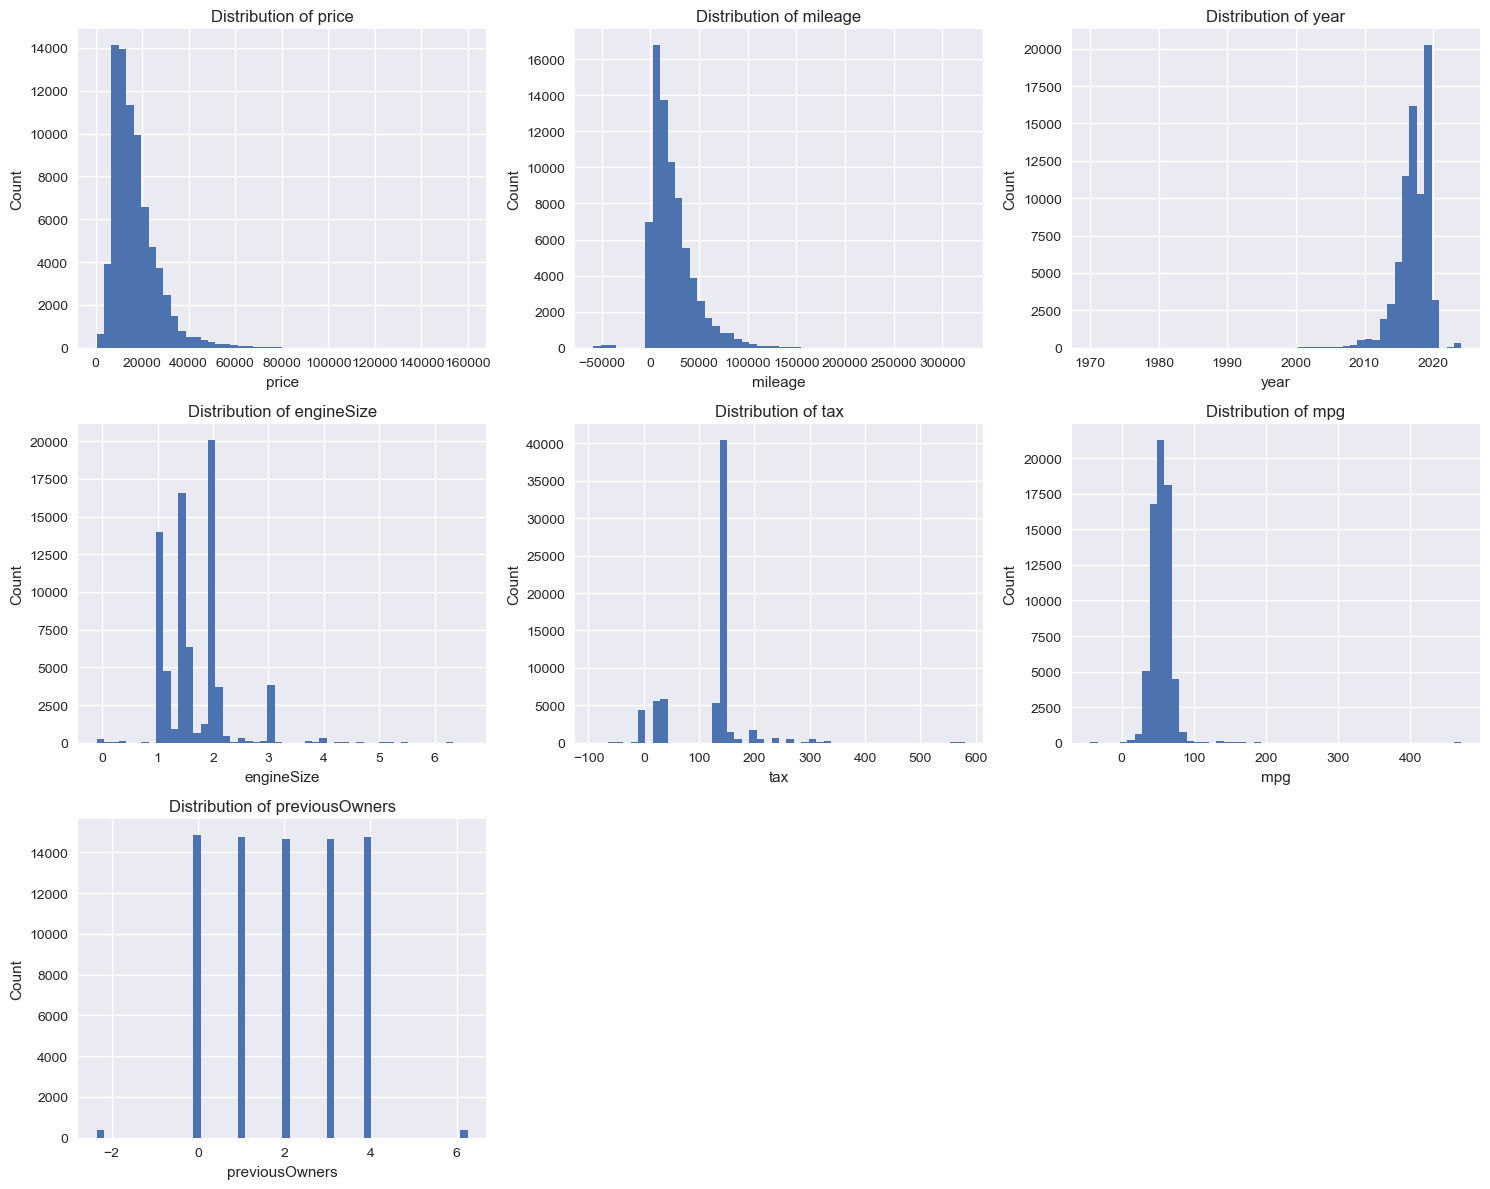

In [7]:
# Pick common numeric columns if present
num_candidates = [c for c in ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg', 'previousOwners'] if c in df.columns]

# Determine grid size (3 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to iterate easily

for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


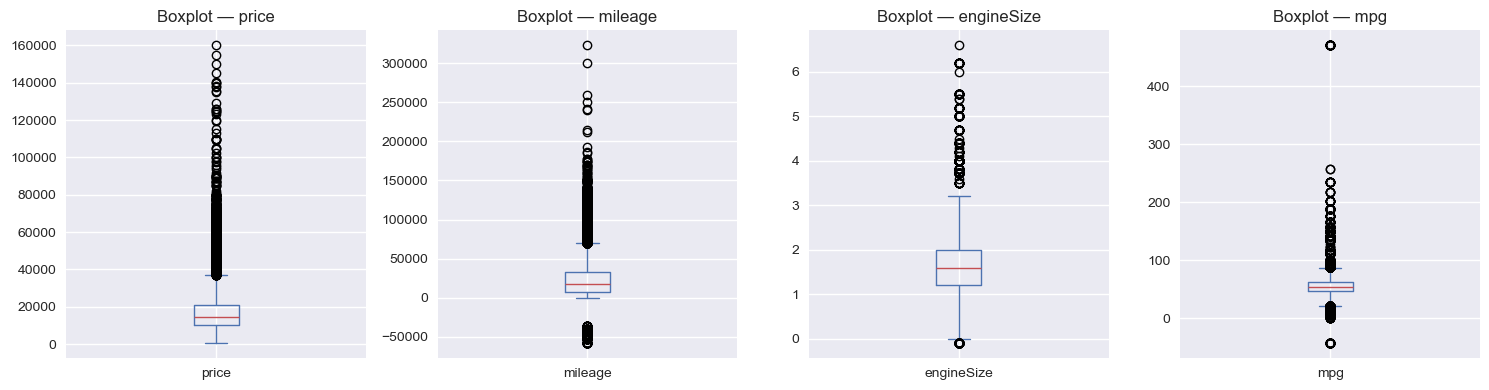

In [8]:
# Select numeric columns available
num_candidates = [c for c in ['price', 'mileage', 'engineSize', 'mpg'] if c in df.columns]

# Set grid layout (4 columns per row)
n_cols = 4
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_candidates):
    ax = axes[i]
    df[[col]].dropna().plot(kind="box", ax=ax, title=f"Boxplot — {col}")
    ax.set_xlabel("")  # cleaner look

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Several numerical features, including mileage and mpg, contain outliers on both the lower and upper ends of the distribution. However, the majority of extreme values appear on the higher end, suggesting the presence of unusually large measurements.**

## 6. Categorical Overview

In [9]:
# Identify all categorical columns (dtype 'object') in the DataFrame
cat_cols = [c for c in df.columns if df[c].dtype=='object']

# Initialize a list to store summary DataFrames for each categorical column
summary = []

# Loop over each categorical column
for c in cat_cols:
    # Get value counts for the column, including NaN, limited to the top 15 categories
    vc = df[c].value_counts(dropna=False).head(15)
    
    # Create a DataFrame with the category names and counts, add the column name
    summary.append(pd.DataFrame({
        "category": vc.index.astype(str),  # Ensure categories are strings
        "count": vc.values
    }).assign(column=c))

# If there are any categorical columns, concatenate their summaries and display the first 50 rows of the summary DataFrame
if summary:
    summary_df = pd.concat(summary, ignore_index=True)
    display(summary_df.head(50))
else:
    # If not inform the user if no categorical columns were found
    print("No categorical columns detected.")

,category,count,column
0,Ford,14808,Brand
1,Mercedes,10754,Brand
2,VW,9780,Brand
3,Opel,8645,Brand
4,BMW,6968,Brand
5,Audi,6749,Brand
6,Toyota,4289,Brand
7,Skoda,3973,Brand
8,Hyundai,3066,Brand
9,nan,1521,Brand


**By observing the top categories for each categorical column, we can identify likely invalid or misspelled entries.  
For example, in `Brand` we see `'ord'` instead of `'Ford'` and `'ercedes'` instead of `'Mercedes'`.  
Similar issues may exist in `Model`, `Transmission`, or `FuelType`, indicating a need for data cleaning.**

## 7. Correlation Analysis (Numerical)

In [10]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr(numeric_only=True)
    # Focus table around 'price' if present
    if 'price' in corr.columns:
        display(corr['price'].sort_values(ascending=False))
    display(corr)
else:
    print("Not enough numeric columns for correlation matrix.")


price             1.000000
engineSize        0.612243
year              0.475712
tax               0.297102
paintQuality%     0.000256
previousOwners   -0.000030
carID            -0.197381
mpg              -0.285626
mileage          -0.405266
hasDamage              NaN
Name: price, dtype: float64

,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,1.000000,0.018276,-0.197381,-0.037122,-0.047918,-0.010129,-0.185361,-0.006262,0.000163,NaN
year,0.018276,1.000000,0.475712,-0.669436,0.179040,-0.123254,-0.038421,0.004117,0.000483,NaN
price,-0.197381,0.475712,1.000000,-0.405266,0.297102,-0.285626,0.612243,0.000256,-0.000030,NaN
mileage,-0.037122,-0.669436,-0.405266,1.000000,-0.202249,0.166973,0.099207,-0.001456,0.001691,NaN
tax,-0.047918,0.179040,0.297102,-0.202249,1.000000,-0.418794,0.256719,0.006450,0.002589,NaN
mpg,-0.010129,-0.123254,-0.285626,0.166973,-0.418794,1.000000,-0.227497,-0.002703,-0.001166,NaN
engineSize,-0.185361,-0.038421,0.612243,0.099207,0.256719,-0.227497,1.000000,0.005137,0.000755,NaN
paintQuality%,-0.006262,0.004117,0.000256,-0.001456,0.006450,-0.002703,0.005137,1.000000,-0.006318,NaN
previousOwners,0.000163,0.000483,-0.000030,0.001691,0.002589,-0.001166,0.000755,-0.006318,1.000000,NaN
hasDamage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Bivariate Relations w.r.t. Target (`price`)

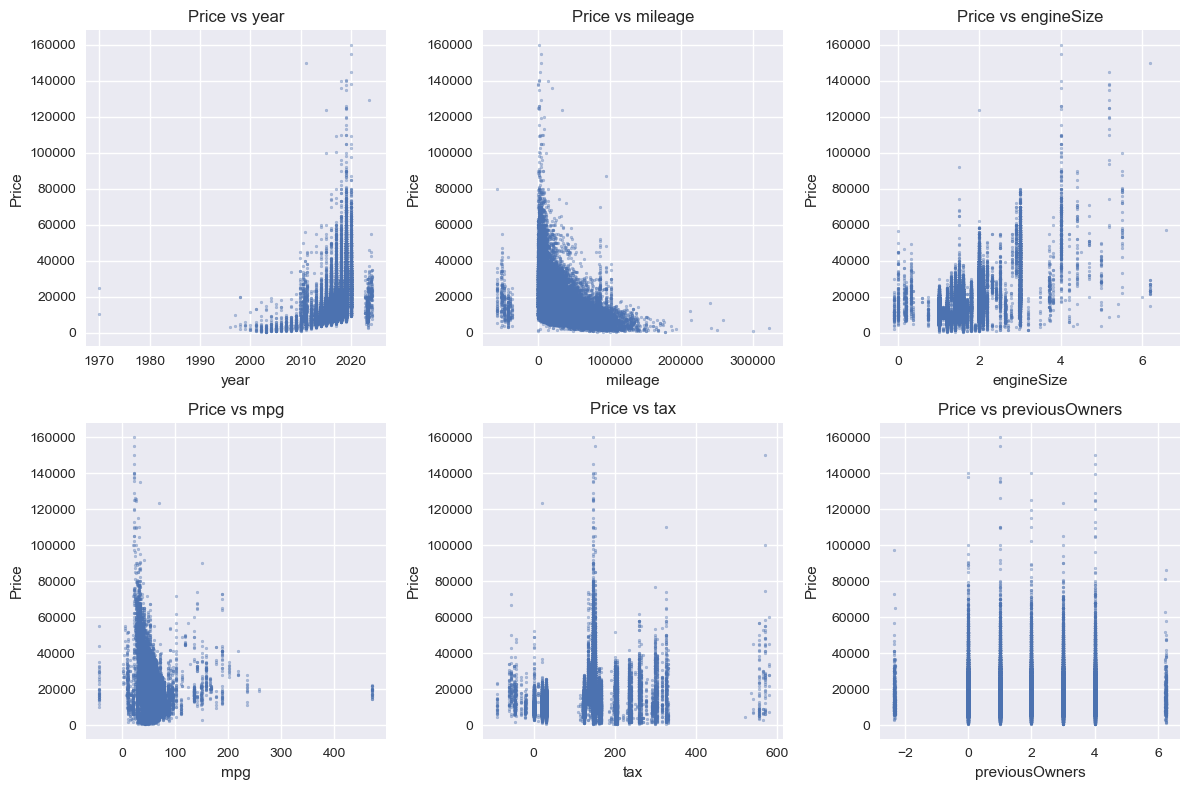

In [11]:
import matplotlib.pyplot as plt

# Select numeric predictors available
num_candidates = [c for c in ['year', 'mileage', 'engineSize', 'mpg', 'tax', 'previousOwners'] if c in df.columns]
    
# Define grid layout (2 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_candidates):
    ax = axes[i]
    ax.scatter(df[col], df['price'], s=4, alpha=0.4)
    ax.set_title(f"Price vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Price")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [12]:
# Price by top categories (Brand, fuelType), if present
for cat in [c for c in ['Brand','fuelType','model','hasDamage'] if c in df.columns]:
    top = df[cat].value_counts().head(10).index
    gdf = df[df[cat].isin(top)].groupby(cat)['price'].agg(['count','mean','median']).sort_values('mean', ascending=False)
    print(f"== {cat} — top 10 by frequency ==")
    display(gdf)

== Brand — top 10 by frequency ==


,count,mean,median
Brand,,,
Mercedes,10754,24489.382369,22685.5
Audi,6749,22899.203586,20444.0
BMW,6968,22643.574627,20136.0
VW,9780,16897.048057,15698.0
Skoda,3973,14255.603826,13000.0
FORD,316,13047.205696,11993.0
Hyundai,3066,12827.721135,11998.0
Ford,14808,12587.366626,11750.0
Toyota,4289,12499.829564,10707.0


== fuelType — top 10 by frequency ==


,count,mean,median
fuelType,,,
iesel,603,19424.061360,17890.0
Hybrid,2043,19346.669604,18310.0
diesel,599,19293.726210,17000.0
Diesel,28474,19189.271125,17191.0
Diese,582,19001.769759,16985.0
petrol,746,15377.605898,12995.0
Petrol,37995,15017.945124,12490.0
PETROL,795,14979.805031,12299.0
Petro,785,14953.598726,12250.0


== model — top 10 by frequency ==


,count,mean,median
model,,,
C Class,4886,23742.119730,22999.0
A Class,1618,20013.948702,18395.0
3 Series,1566,19707.333972,18005.0
Golf,3081,16758.799416,16042.0
Kuga,1382,15772.583213,15845.0
Focus,6353,13411.979852,13000.0
Polo,2046,11327.741935,10750.0
Astra,1744,10439.630734,10208.5
Fiesta,4130,10234.486441,9995.0


== hasDamage — top 10 by frequency ==


,count,mean,median
hasDamage,,,
0.0,74425,16883.212509,14698.0


## 9. Data Quality Checks

In [15]:
# Duplicates by a likely ID if present
id_cols = [c for c in ['carID','id'] if c in df.columns]
if id_cols:
    for cid in id_cols:
        dup_n = df.duplicated(subset=[cid]).sum()
        print(f"Duplicates by {cid}: {dup_n}")
else:
    print("No explicit ID column found; skipping duplicate check by ID.")

# check numerical categories for numbers smaller than 0 and sum them
print((df.select_dtypes(include=['number']) < 0).sum())
# calculate the percentage
print(((df.select_dtypes(include=['number']) < 0).sum() / len(df)) * 100)
# data from 2020 -> newer cars should not exist
print("Cars with year greater then 2020: " + str((df['year'] > 2020).sum()))
# paint cannot be better quality then 100 percent
print("Cars with better quality then 100 percent: " + str((df['paintQuality%'] > 100).sum()))
# Engine Size should be between 0.8 and 6.2
print("Cars with unusual engine size: " + str(((df['engineSize'] > 6.2) | (df['engineSize'] < 0.8)).sum()))
# Some mpg values could be unrealistic as well
unusual_mpg_mask = ((df['mpg'] > 150) & (df["fuelType"] == "electric")) | \
       ((df['mpg'] < 70) & (df["fuelType"] == "electric")) | \
       ((df['mpg'] > 100) & (df["fuelType"] == "hybrid")) | \
       ((df['mpg'] < 35) & (df["fuelType"] == "hybrid")) | \
       ((df['mpg'] > 80) & (df["fuelType"] != "hybrid") & (df["fuelType"] != "electric")) | \
       ((df['mpg'] < 8) & (df["fuelType"] != "hybrid")& (df["fuelType"] != "electric"))
# still have to rplace the previous numbres with valid (look for sources)
print("Cars with unusual mpg: ", unusual_mpg_mask.sum())
# previous owners, and years have to be an integer
int_cols = ['year', 'previousOwners']

for col in int_cols:
    non_int_mask = (df[col] % 1 != 0)
    count_non_int = non_int_mask.sum()
    print("Float numbers in " + f"{col}: {count_non_int} non-integer values")

Duplicates by carID: 0
carID               0
year                0
price               0
mileage           369
tax               378
mpg                36
engineSize         84
paintQuality%       0
previousOwners    371
hasDamage           0
dtype: int64
carID             0.000000
year              0.000000
price             0.000000
mileage           0.485699
tax               0.497545
mpg               0.047385
engineSize        0.110566
paintQuality%     0.000000
previousOwners    0.488331
hasDamage         0.000000
dtype: float64
Cars with year greater then 2020: 358
Cars with better quality then 100 percent: 367
Cars with unusual engine size: 575
Cars with unusual mpg:  1483
Float numbers in year: 2214 non-integer values
Float numbers in previousOwners: 2284 non-integer values


In [17]:
print(df["year"].value_counts(dropna=False))
mean_mileage = df.groupby("year")['mileage'].mean().reset_index()
float_years = mean_mileage[mean_mileage['year'] % 1 != 0]
int_years = mean_mileage[mean_mileage['year'] % 1 == 0]
print(float_years)
print(int_years)

year
2019.000000    20271
2017.000000    16146
2016.000000    11502
2018.000000    10304
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
NaN             1491
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2011.111188       15
2001.000000       15
2022.878006       12
2000.000000        6
1998.000000        5
1999.000000        5
1970.000000        2
1997.000000        2
1996.000000        1
Name: count, dtype: int64
           year       mi

tax_sign
negative    -45.78061
positive    145.00000
Name: tax, dtype: float64


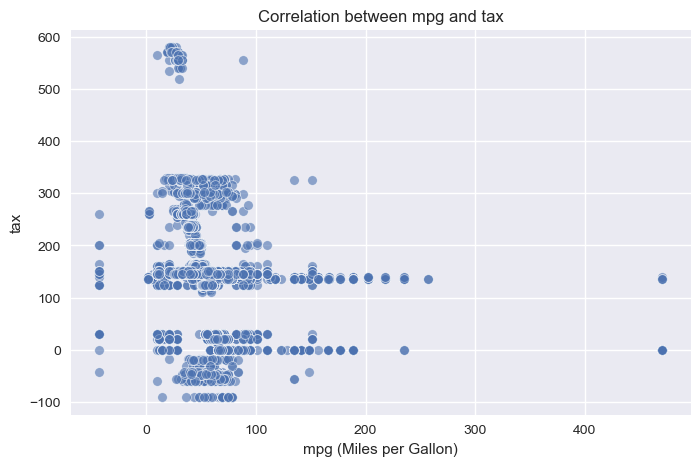

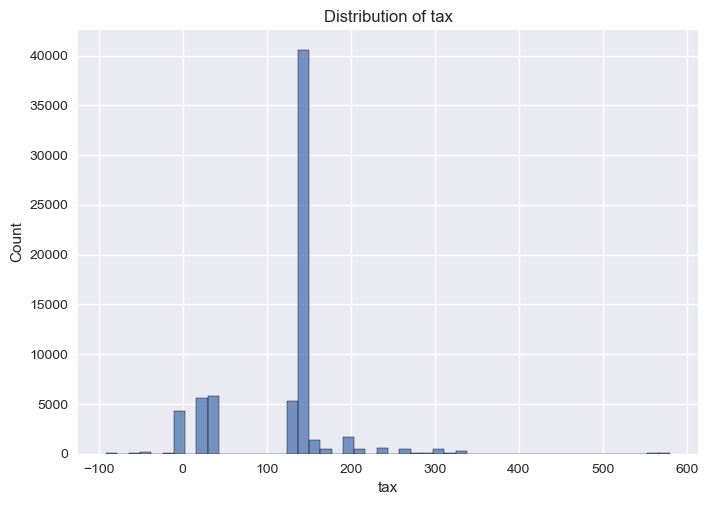

In [19]:
# compare the median negative values for tax to the median positive value
# to see, if it is just a sign error
avg_tax_by_year = df.assign(
    tax_sign = np.where(df['tax'] < 0, 'negative', 'positive')
).groupby(['tax_sign'])['tax'].median()
print(avg_tax_by_year)

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='mpg', y='tax', alpha=0.6)
plt.title('Correlation between mpg and tax')
plt.xlabel('mpg (Miles per Gallon)')
plt.ylabel('tax')
plt.show()

sns.histplot(data=df, x='tax', bins=50)
plt.title('Distribution of tax')
plt.show()

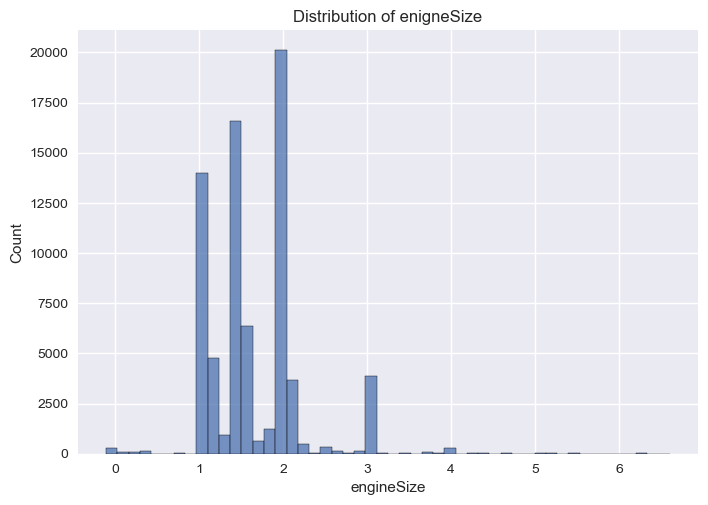

In [20]:
# now we look at the enigneSize histogram
sns.histplot(data=df, x='engineSize', bins=50)
plt.title('Distribution of enigneSize')
plt.show()

In [21]:
# compare the mileage mean negative values of a year to the mean mileage positive value of a year 
# to see, if it is just a sign error
# 1970 also looks weird
avg_mileage_by_year = df.assign(
    mileage_sign = np.where(df['mileage'] < 0, 'negative', 'positive')
).groupby(['year', 'mileage_sign'])['mileage'].mean().unstack()
print(avg_mileage_by_year)

mileage_sign      negative      positive
year                                    
1970.000000            NaN  25678.500000
1996.000000            NaN  50000.000000
1997.000000            NaN  62500.000000
1998.000000            NaN  67147.750000
1999.000000            NaN  61446.200000
2000.000000            NaN  66589.200000
2001.000000            NaN  65864.466667
2002.000000  -52618.457894  83498.181818
2003.000000            NaN  89402.894139
2004.000000  -58540.574478  93506.562500
2005.000000            NaN  92521.210736
2006.000000            NaN  87987.370968
2007.000000  -50755.210230  85368.866088
2008.000000  -42707.564215  90949.845161
2009.000000  -42707.564215  82456.742820
2009.816757            NaN  31150.891892
2010.000000  -48568.891663  81670.193966
2010.268635            NaN  24029.684211
2010.371546            NaN  18839.714286
2010.565009            NaN  23144.383813
2010.676968  -42650.453719  20625.012658
2010.746403            NaN  19030.912281
2011.000000  -47

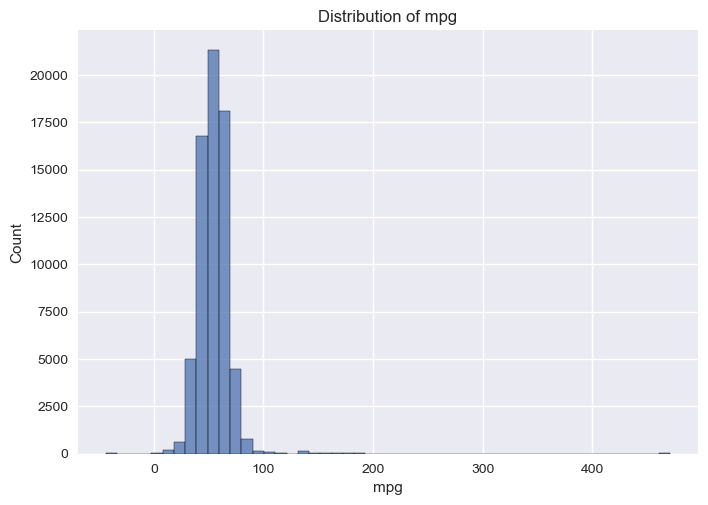

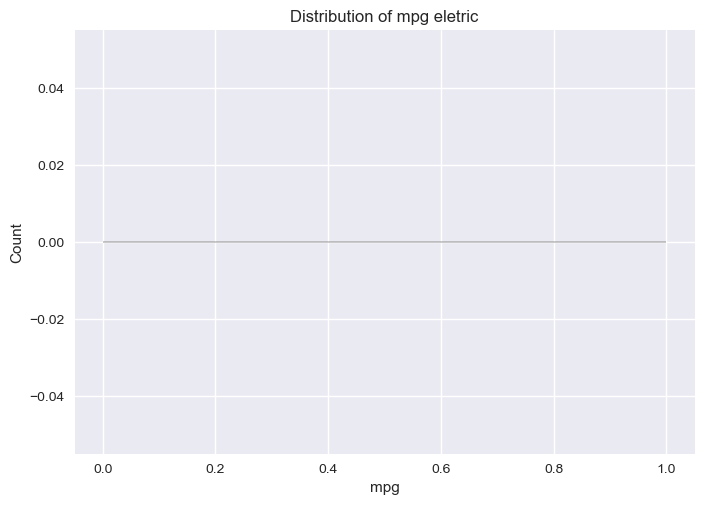

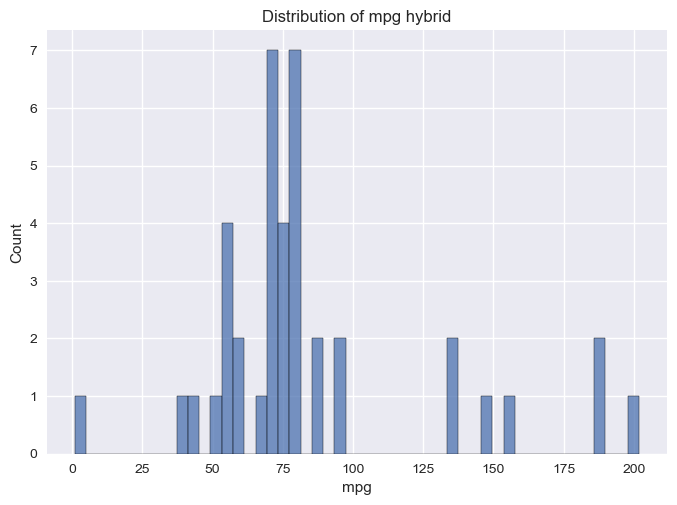

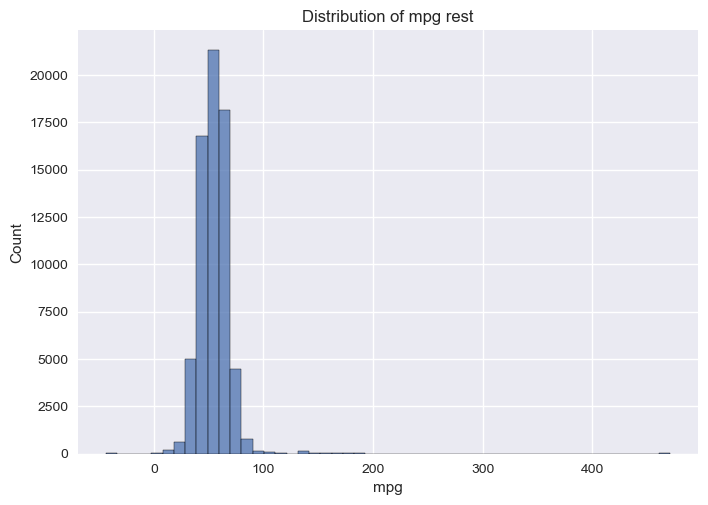

In [22]:
# now we look at the mpg histogram
sns.histplot(data=df, x='mpg', bins=50)
plt.title('Distribution of mpg')
plt.show()
sns.histplot(data=df[df["fuelType"] == "electric"], x='mpg', bins=50)
plt.title('Distribution of mpg eletric')
plt.show()
sns.histplot(data=df[df["fuelType"] == "hybrid"], x='mpg', bins=50)
plt.title('Distribution of mpg hybrid')
plt.show()
sns.histplot(data=df[(df["fuelType"] != "hybrid")& (df["fuelType"] != "electric")], x='mpg', bins=50)
plt.title('Distribution of mpg rest')
plt.show()


## 10. Key Findings for the next step



Here we write some text with our findings to summarize the EDA and justify the next steps.